In [1]:
import os, pickle, tempfile
import pandas as pd

In [2]:
import sys

sys.path.append("../../training_data")

In [3]:
from utils.utils import Cif, CifFileWriter
from utils.pocket_utils import Pocket

# Data

In [4]:
extra_set_path = "../../training_data/8.Apos/Extra_set"

In [5]:
with open(f"{extra_set_path}/pockets_features.pkl", "rb") as f:
    news = pickle.load(f)

len(news), news

(19,
 {'8sgj':    Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
  0     8sgj  pocket16   12        0.00000       0.000000     0      -0.0342   
  1     8sgj  pocket28   14        0.00000       0.000000     0      -0.1447   
  2     8sgj  pocket18   13        0.03125       0.076923     0      -0.0508   
  3     8sgj  pocket11   19        0.00000       0.000000     0       0.0417   
  4     8sgj  pocket25   13        0.00000       0.000000     0      -0.1152   
  5     8sgj  pocket15    9        0.03125       0.111111     0      -0.0332   
  6     8sgj   pocket7    8        0.03125       0.125000     0       0.1316   
  7     8sgj  pocket22   10        0.00000       0.000000     0      -0.0848   
  8     8sgj  pocket13    8        0.00000       0.000000     0       0.0031   
  9     8sgj  pocket23   40        0.00000       0.000000     0      -0.1057   
  10    8sgj  pocket14    9

In [6]:
with open(f"{extra_set_path}/apos_sites.pkl", "rb") as f:
    news_sites =  {k: [{"site": s["site"]} for s in v.values()] for k,v in pickle.load(f).items() if k in news}

len(news_sites), news_sites

(19,
 {'8sgj': [{'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            GLU             A               1          132                 ?   
    1            THR             A               1          133                 ?   
    2            VAL             A               1          134                 ?   
    3            SER             A               1          135                 ?   
    4            LEU             A               1          137                 ?   
    5            THR             A               1          138                 ?   
    6            ALA             A               1          141                 ?   
    7            HIS             A               1          200                 ?   
    8            VAL             A               1          203                 ?   
    9            VAL             A               1          206                 ?   
    10           THR             A          

In [7]:
with open(f"{extra_set_path}/apos.pkl", "rb") as f:
    apos = {k: {k2: v2 for k2, v2 in v.items() if k2 in news} for k, v in pickle.load(f).items()}

len(apos), apos

(19,
 {'8jp0': {'8sgj': ['A']},
  '8f4s': {'7l6r': ['A']},
  '7gqu': {'6yhr': ['A']},
  '7yg5': {'7xlq': ['A']},
  '8v81': {'5uak': ['A']},
  '6z1m': {'6z1h': ['A']},
  '9mfs': {'8szq': ['A']},
  '7p2v': {'6gx3': ['D']},
  '7qpn': {'2gk9': ['A']},
  '7zpe': {'9di9': ['A']},
  '8crc': {'2ojx': ['A']},
  '8fpi': {'6uen': ['A']},
  '8qtk': {'3pfv': ['A']},
  '8y6w': {'8y6y': ['A']},
  '9dol': {'4n22': ['A']},
  '9ebs': {'9di2': ['B']},
  '9fsj': {'9fsk': ['A']},
  '9oul': {'9ouk': ['B']},
  '9prs': {'8yf0': ['A']}})

In [8]:
apos["7qpn"]["2gk9"] = ["A"] # for some reason the .cif that was used has chain A
# apos["9ntc"]["8yf0"] = ["A"]

In [9]:
assert all(len(sites) == 1 for sites in news_sites.values()), "Not all apos have a single annotated site"

In [10]:
models = pd.read_pickle("models_lenient_labelling.pkl")

models

{'model5': {'results': {'2gk9': {'pocket11': {'prob': 0.00021692925656680018,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.09090909090909091,
     'pocket_in_site': 0.09090909090909091,
     'site_in_pocket': 0.045454545454545456},
    'pocket15': {'prob': 0.00947851687669754,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.8571428571428571,
     'pocket_in_site': 0.8571428571428571,
     'site_in_pocket': 0.2727272727272727},
    'pocket7': {'prob': 0.0020677410066127777,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket13': {'prob': 0.008256282657384872,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket14': {'prob': 1.8073738061730182e-08,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.1111111111111111,
     'pocket_in_site': 0.1111111111111111,
     'site_in_pocket': 0.045454545454545456},
    'pocket1': {'

In [11]:
colors = {
    "orange": "#D55E00".lower(),
    "green": "#009E73".lower(),
    "blue": "#0072B2".lower(),
    "yellow": "#F0E442".lower()
}

# Labelling

In [12]:
# Percentage of residues of "one" in "other"
get_overlap = lambda one, other: (
    len( one.merge(other) ) / len(one)
)

def get_label(overlaps, site_in_pocket=None, pocket_in_site=None):
    assert not (site_in_pocket==None and pocket_in_site==None)
    
    if site_in_pocket is None:
        return int( overlaps["pocket_in_site"] >= pocket_in_site )
    if pocket_in_site is None:
        return int( overlaps["site_in_pocket"] >= site_in_pocket )
    return int( overlaps["site_in_pocket"] >= site_in_pocket or overlaps["pocket_in_site"] >= pocket_in_site )

In [13]:
get_overlaps = lambda pdb, pocketd: max(
    (
        {
            name: get_overlap(*one_in_other)
            for name, one_in_other in (
                ("pocket_in_site", (pocketd["residues"], site["site"])),
                ("site_in_pocket", (site["site"], pocketd["residues"])),
            )
        }
        for site in news_sites[pdb]
    ),
    key=lambda x: x["site_in_pocket"]
)


# get_overlaps_special = lambda pdb, pocketd: max(
#     (
#         {
#             name: get_overlap(*one_in_other)
#             for name, one_in_other in (
#                 ("pocket_in_site", (pocketres, site)),
#                 ("site_in_pocket", (site, pocketres)),
#             )
#         }
#         for pocketres in (pocketd["residues"],)
#             for sitei in news_sites[pdb]
#                 for site in (sitei["site"].query(f"auth_asym_id == '{pocketres.auth_asym_id.unique().item()}'"),)
#     ),
#     key=lambda x: x["site_in_pocket"]
# )
def get_overlaps_special(a,b): 
    raise Exception("This function should not be called")

In [14]:
def label_results(resultsd, site_in_pocket=0.35, pocket_in_site=None, prob_key=None, topx=False, special_7sns_sc=False):
    df = pd.DataFrame((
        {
            "pdb": pdb,
            "pocket": pocket,
            **{"prob": pocketd[prob_key] for prob_key in (prob_key,) if prob_key is not None},
            "pred": pocketd["pred"],
            "label": get_label(overlaps, site_in_pocket, pocket_in_site),
            "max_overlap": max(overlaps.values()),
            **overlaps,
        }
        for pdb, pockets in resultsd.items()
            # if pdb != "4jqi"
        for pocket, pocketd in pockets.items()
        for overlaps in (get_overlaps(pdb, pocketd),)
        # ((
        #     get_overlaps_special(pdb, pocketd)
        #     if special_7sns_sc and pdb == "7sns"
        #     else get_overlaps(pdb, pocketd)
        # ),)
    ))
    
    if prob_key is not None and topx:
        df["pred"] = (
            # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
            df.groupby("pdb")["label"].transform("sum")
            # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
            .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
            # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
            >= 0
        ).astype(int)
        # If a PDB has no + labelled pocket, assign the highest prob. as positive
        for pdb, group in df.groupby("pdb"):
            if group["pred"].sum() == 0:
                df.loc[ group["prob"].idxmax(), "pred" ] = 1
    
    return df.sort_values("max_overlap", ascending=False)

In [15]:
for model, modeld in models.items():
    if model not in ["model5", "mefallosite", "allo"]: continue

    
    if model != "model5":
        models[model]["labelled"] = label_results(
            modeld["results"], 
            **modeld["labelling"], 
            prob_key=modeld["prob_key"],
            topx=True
        )
    else:
        if "labelled" in modeld:
            continue
        # models[model]["labelled"] = label_our_results(
        #     modeld["results"], 
        #     # **modeld["labelling"]
        # )
        df = pd.DataFrame((
            {
                "pdb": pdb,
                "pocket": pocket,
                **pocketd
            }
            for pdb, pockets in modeld["results"].items()
                if pdb != "4jqi"
            for pocket, pocketd in pockets.items()
        ))
        
        df["pred"] = (
            # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
            df.groupby("pdb")["label"].transform("sum")
            # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
            .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
            # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
            >= 0
        ).astype(int)
        # If a PDB has no + labelled pocket, assign the highest prob. as positive
        for pdb, group in df.groupby("pdb"):
            if group["pred"].sum() == 0:
                df.loc[ group["prob"].idxmax(), "pred" ] = 1

        models[model]["labelled"] = df

In [16]:
models["model5"]["labelled"]

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket,rank
357,8sgj,pocket16,0.001242,0,0,0.000000,0.000000,0.00000,11
358,8sgj,pocket28,0.000066,0,0,0.000000,0.000000,0.00000,22
359,8sgj,pocket18,0.000034,0,0,0.076923,0.076923,0.03125,25
360,8sgj,pocket11,0.001370,0,0,0.000000,0.000000,0.00000,9
361,8sgj,pocket25,0.001211,0,0,0.000000,0.000000,0.00000,12
...,...,...,...,...,...,...,...,...,...
460,8yf0,pocket3,0.001070,0,0,0.000000,0.000000,0.00000,12
461,8yf0,pocket12,0.001113,0,0,0.000000,0.000000,0.00000,11
462,8yf0,pocket19,0.000052,0,0,0.000000,0.000000,0.00000,21
463,8yf0,pocket21,0.001741,0,0,0.000000,0.000000,0.00000,6


# Scatters

## Ortho sites

In [17]:
holo_ortho_sites = pd.read_pickle("../other_tools/ortho_sites/ortho_sites.pkl")
holo_ortho_sites.keys(), holo_ortho_sites

(dict_keys(['7gqu', '8f4s', '8uk6', '8v81', '9ebs', '9mfs', '9oul', '22mj', '6s3a', '6z1m', '7p2v', '7qpn', '7zpe', '8crc', '8fpi', '21du', '8y6w', '9dol', '9prs']),
 {'7gqu': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           38                 ?   
   7            ALA             A               1           57                 ?   
   8            THR             A               1           58        

In [18]:
# PDBs that do not have a UniProt column for apo ortho site cross-annotation
for holo, osites in holo_ortho_sites.items():
    if holo in apos:
        for apo in (tuple(apos[holo].keys())[0],):
            for apocif in (Cif(apo, f"structures/{apo}.cif"),):
                for osite in osites:
                    if "pdbx_sifts_xref_db_acc" not in osite.columns:
                        print(holo)#[[, "pdbx_sifts_xref_db_num"]]
                

9mfs
6z1m


In [19]:
ortho_sites = {
    apo: [
        chainres
        for osite in osites
        for chain, chainres in apocif.residues.merge(
            osite[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].drop_duplicates()
        ).groupby("label_asym_id")
    ]
    for holo, osites in holo_ortho_sites.items()
    if holo in apos and holo not in ("6z1m", "9mfs")
        for apo in (tuple(apos[holo].keys())[0],)
        for apocif in (Cif(apo, f"structures/{apo}.cif"),)
}

len(ortho_sites), {k1: {k2: len(v2) for k2, v2 in enumerate(v1, 1)} for k1, v1 in ortho_sites.items()}, ortho_sites

(13,
 {'6yhr': {1: 21},
  '7l6r': {1: 30},
  '5uak': {1: 28},
  '9di2': {1: 12},
  '9ouk': {1: 14},
  '6gx3': {1: 20},
  '2gk9': {1: 18},
  '9di9': {1: 28},
  '2ojx': {1: 11},
  '6uen': {1: 17},
  '8y6y': {1: 25},
  '4n22': {1: 20},
  '8yf0': {1: 19}},
 {'6yhr': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           38                 ?   
   7            ALA             A               1           57     

For 6z1m and 9mfs the label_asym_id and label_seq_id coincide with their apos.

<br>

In [20]:
ortho_sites.update({
    apo: [
        chainres
        for osite in osites
        for chain, chainres in apocif.residues.merge(
            osite[["label_asym_id", "label_seq_id"]].drop_duplicates()
        ).groupby("label_asym_id")
    ]
    for holo, osites in holo_ortho_sites.items()
    if holo in apos and holo in ("6z1m", "9mfs")
        for apo in (tuple(apos[holo].keys())[0],)
        for apocif in (Cif(apo, f"structures/{apo}.cif"),)
})

len(ortho_sites), {k1: {k2: len(v2) for k2, v2 in enumerate(v1, 1)} for k1, v1 in ortho_sites.items()}, ortho_sites

(15,
 {'6yhr': {1: 21},
  '7l6r': {1: 30},
  '5uak': {1: 28},
  '9di2': {1: 12},
  '9ouk': {1: 14},
  '6gx3': {1: 20},
  '2gk9': {1: 18},
  '9di9': {1: 28},
  '2ojx': {1: 11},
  '6uen': {1: 17},
  '8y6y': {1: 25},
  '4n22': {1: 20},
  '8yf0': {1: 19},
  '8szq': {1: 27},
  '6z1h': {1: 26}},
 {'6yhr': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           38                 ?   
   7            ALA          

In [21]:
ortho_labels = {}

for pdb, pdbd in models["model5"]["labelled"].groupby("pdb"):#.items():
    if pdb not in ortho_sites: continue
        
    ortho_sites_pdb = ortho_sites[pdb]
    ortho_labels[pdb] = {}
    
    for pocket, pocketd in pdbd.groupby("pocket"):#.items():
        pocketres = Pocket(f"../../training_data/8.Apos/Extra_set/pockets/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif").residues

        overlaps = max(
            (
                {
                    name: get_overlap(*one_in_other)
                        for name, one_in_other in (
                            ("pocket_in_site", (pocketres, site)),
                            ("site_in_pocket", (site, pocketres)),
                        )
                }
                for site in ortho_sites_pdb # will probably be only 1 site so only 1 value for the max()
            ),
            key=lambda x: x["site_in_pocket"]
        )
        
        ortho_labels[pdb][pocket] = {
            "ortho_label": get_label(overlaps, site_in_pocket=0.65, pocket_in_site=None),
            "ortho_max_overlap": max(overlaps.values()),
            **{f"ortho_{k}": v for k, v in overlaps.items()},
            **pocketd.squeeze().to_dict()
        }

ortho_labels.keys(), ortho_labels

(dict_keys(['2gk9', '2ojx', '4n22', '5uak', '6gx3', '6uen', '6yhr', '6z1h', '7l6r', '8szq', '8y6y', '8yf0', '9di2', '9di9', '9ouk']),
 {'2gk9': {'pocket1': {'ortho_label': 1,
    'ortho_max_overlap': 0.8888888888888888,
    'ortho_pocket_in_site': 0.5161290322580645,
    'ortho_site_in_pocket': 0.8888888888888888,
    'pdb': '2gk9',
    'pocket': 'pocket1',
    'prob': 0.6147716045379639,
    'pred': 1,
    'label': 1,
    'max_overlap': 0.4090909090909091,
    'pocket_in_site': 0.2903225806451613,
    'site_in_pocket': 0.4090909090909091,
    'rank': 1},
   'pocket10': {'ortho_label': 0,
    'ortho_max_overlap': 0.0,
    'ortho_pocket_in_site': 0.0,
    'ortho_site_in_pocket': 0.0,
    'pdb': '2gk9',
    'pocket': 'pocket10',
    'prob': 6.406293687177822e-05,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0,
    'rank': 11},
   'pocket11': {'ortho_label': 0,
    'ortho_max_overlap': 0.2727272727272727,
    'ortho_pocket_in_si

In [22]:
pd.DataFrame((
    {
        "pdb": pdb,
        "pocket": pocket,
        **pocketd
    }
    for pdb, pockets in ortho_labels.items()
    for pocket, pocketd in pockets.items()
)).sort_values("ortho_max_overlap", ascending=False).iloc[:40]

,pdb,pocket,ortho_label,ortho_max_overlap,ortho_pocket_in_site,ortho_site_in_pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket,rank
320,8yf0,pocket1,1,0.947368,0.197802,0.947368,8.722903e-01,1,1,0.757576,0.274725,0.757576,1
140,6uen,pocket1,1,0.941176,0.107383,0.941176,9.881197e-01,1,0,0.000000,0.000000,0.000000,1
370,9di9,pocket2,0,0.928571,0.928571,0.464286,1.721100e-02,0,0,0.071429,0.071429,0.071429,4
131,6gx3,pocket2,1,0.900000,0.900000,0.900000,5.964910e-01,1,0,0.000000,0.000000,0.000000,1
304,8szq,pocket8,1,0.888889,0.400000,0.888889,7.677208e-01,0,0,0.000000,0.000000,0.000000,2
0,2gk9,pocket1,1,0.888889,0.516129,0.888889,6.147716e-01,1,1,0.409091,0.290323,0.409091,1
223,6yhr,pocket1,1,0.857143,0.243243,0.857143,5.108915e-01,1,1,0.379310,0.148649,0.379310,1
368,9di2,pocket9,1,0.833333,0.666667,0.833333,1.534538e-03,0,0,0.066667,0.066667,0.035714,8
383,9ouk,pocket14,0,0.818182,0.818182,0.642857,1.039904e-01,0,0,0.000000,0.000000,0.000000,3
19,2ojx,pocket5,1,0.818182,0.818182,0.818182,1.310654e-03,0,0,0.090909,0.090909,0.076923,2


In [23]:
ortho_pockets = {
    "6z1h": ("pocket1",),
    "6yhr": ("pocket1",),
    "6gx3": ("pocket2",),
    "2gk9": ("pocket1",),
    # 7xlq | 7yg5
    "9di9": ("pocket2", "pocket9",),
    "2ojx": ("pocket5",),
    "7l6r": ("pocket3",),
    "6uen": ("pocket1",),
    # 8sgj
    # 3pfv (prev. 8vw5)
    "5uak": ("pocket5",),#, "pocket39", "pocket4", "pocket54",),
    "8y6y": ("pocket8",),
    "4n22": ("pocket3",),
    "9di2": ("pocket9",),
    # 9fsj | 9fsk
    "8szq": ("pocket8",),
    "9ouk": ("pocket14",),
    "8yf0": ("pocket1",),
}

ortho_pocketsf = "ortho_pockets.pkl"
pd.to_pickle(ortho_pockets, ortho_pocketsf)

ortho_pockets

{'6z1h': ('pocket1',),
 '6yhr': ('pocket1',),
 '6gx3': ('pocket2',),
 '2gk9': ('pocket1',),
 '9di9': ('pocket2', 'pocket9'),
 '2ojx': ('pocket5',),
 '7l6r': ('pocket3',),
 '6uen': ('pocket1',),
 '5uak': ('pocket5',),
 '8y6y': ('pocket8',),
 '4n22': ('pocket3',),
 '9di2': ('pocket9',),
 '8szq': ('pocket8',),
 '9ouk': ('pocket14',),
 '8yf0': ('pocket1',)}

## Plots

In [24]:
df = models["model5"]["labelled"]

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

scatter_config = {
    "figsize": (1.75, 2.25),
    "point_size": 50,
    "jitter_width": 0.2,
    "grey_alpha": 0.4,
    "axis_linewidth": 0.8,
    "tick_fontsize": 12,
    "label_fontsize": 15,
    "xlabel_fontsize": 12,
    "score_title_fontsize": 13,
    "score_title_y": 1.12,
    "annotation_x_offset": 0.4,
    "yticks": [0.0, 0.25, 0.5, 0.75, 1.0],
    "ylabel_right_spine_position": 0.8125,
    "special_nbins": {"9di9": 1},
    "blue_x_shift_by_pdb": {"9di9": -0.125},
    "light_grey": "0.75",
    "xlabel_color": "0.35",
    "output_prefix": "images/boxplot_",
}

plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"
rcParams["axes.linewidth"] = scatter_config["axis_linewidth"]


def get_scatter_point_color(row, light_grey=None):
    light_grey = light_grey or scatter_config["light_grey"]
    if row["pdb"] in ortho_pockets and row["pdb"] not in ("6yhr", "2gk9", "8yf0"):
        if row["pocket"] in ortho_pockets[row["pdb"]]:
            return colors["yellow"]
    if row["pred"] and row["label"]:
        return colors["green"]
    if row["label"]:
        return colors["orange"]
    if row["pred"]:
        return colors["blue"]
    return light_grey


def get_beeswarm_offsets(probs, pdb_id, jitter_width, special_nbins=None):
    probs = np.asarray(probs, dtype=float)
    if probs.size == 0 or np.nanmax(probs) == np.nanmin(probs):
        return np.zeros_like(probs)

    nbins = (special_nbins or {}).get(pdb_id, 50)
    rng = np.random.default_rng(0)
    quant = np.round(
        nbins * (probs - np.nanmin(probs)) / (np.nanmax(probs) - np.nanmin(probs) + 1e-8)
    )
    order = np.argsort(quant + rng.normal(0, 1e-6, len(probs)))

    x_vals = np.zeros(len(probs))
    layer = 0
    last_bin = None

    for idx in order:
        if quant[idx] != last_bin:
            layer = 0
            last_bin = quant[idx]

        if layer == 0:
            offset = 0
        else:
            offset = (layer + 1) // 2
            if layer % 2 == 0:
                offset = -offset

        x_vals[idx] = offset
        layer += 1

    max_abs = np.max(np.abs(x_vals))
    if max_abs > 0:
        x_vals = x_vals / max_abs * jitter_width
    return x_vals


def plot_scatter_panel(pdb_id, df, ax=None, config=None, show_xlabel=True, show_score_title=True, save_path=None):
    config = {**scatter_config, **(config or {})}
    sub = df.query("pdb == @pdb_id").copy()
    probs = sub["prob"].to_numpy(dtype=float)
    if len(probs) == 0 or np.all(np.isnan(probs)):
        raise ValueError(f"No valid probabilities found for {pdb_id}")

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=config["figsize"])
    else:
        fig = ax.figure

    rcParams["font.size"] = config["label_fontsize"]
    rcParams["ytick.labelsize"] = config["tick_fontsize"]

    sc_colors = np.array([get_scatter_point_color(row) for _, row in sub.iterrows()], dtype=object)
    alphas = np.array([
        config["grey_alpha"] if color == config["light_grey"] else 1
        for color in sc_colors
    ])
    x_vals = get_beeswarm_offsets(
        probs,
        pdb_id=pdb_id,
        jitter_width=config["jitter_width"],
        special_nbins=config["special_nbins"],
    )

    grey_mask = sc_colors == config["light_grey"]
    blue_mask = sc_colors == colors["blue"]
    color_mask = ~(grey_mask | blue_mask)

    ax.scatter(
        x_vals[grey_mask],
        probs[grey_mask],
        s=config["point_size"],
        c=sc_colors[grey_mask],
        alpha=alphas[grey_mask],
        edgecolors="none",
        zorder=1,
        clip_on=False,
    )

    if np.any(color_mask):
        ax.scatter(
            x_vals[color_mask],
            probs[color_mask],
            s=config["point_size"],
            c=sc_colors[color_mask],
            alpha=alphas[color_mask],
            edgecolors="none",
            zorder=2,
            clip_on=False,
        )

    blue_shift = config["blue_x_shift_by_pdb"].get(pdb_id, 0.0)
    if np.any(blue_mask):
        ax.scatter(
            x_vals[blue_mask] + blue_shift,
            probs[blue_mask],
            s=config["point_size"],
            c=sc_colors[blue_mask],
            alpha=alphas[blue_mask],
            edgecolors="none",
            zorder=3,
            clip_on=False,
        )

    idx_max = int(np.nanargmax(probs))
    text_val = f"{probs[idx_max]:.3f}".rstrip("0").rstrip(".")
    ax.text(
        x_vals[idx_max] - config["jitter_width"] * config["annotation_x_offset"] + blue_shift,
        probs[idx_max],
        text_val,
        ha="right",
        va="center",
        fontsize=config["label_fontsize"],
    )

    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(0, 1)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(config["axis_linewidth"])
    ax.spines["right"].set_position(("axes", config["ylabel_right_spine_position"]))

    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    if config["yticks"] is None:
        ax.yaxis.set_major_locator(MaxNLocator(5))
    else:
        ax.set_yticks(config["yticks"])
        ax.set_yticklabels(["0", "", "0.5", "", "1"])
    ax.tick_params(axis="y", labelsize=config["tick_fontsize"])
    ax.set_ylabel("")
    if show_score_title:
        ax.text(
            0,
            config["score_title_y"],
            "AlloPockets\nscore",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            multialignment="center",
            fontsize=config["score_title_fontsize"],
        )
    ax.set_xlabel(f"(n = {len(sub)})" if show_xlabel else "", fontsize=config["xlabel_fontsize"], color=config["xlabel_color"])
    if show_xlabel:
        ax.xaxis.set_label_coords(0.52, -0.075)

    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=300, transparent=True)
        plt.show()
        return fig, ax

    return ax


8sgj


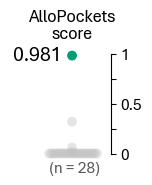

7l6r


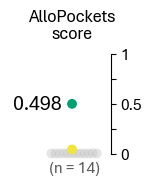

6yhr


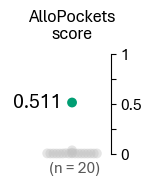

7xlq


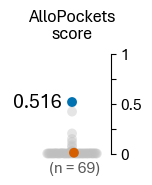

5uak


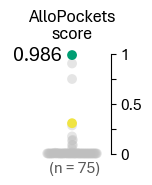

6z1h


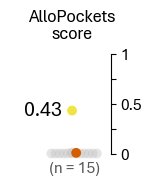

8szq


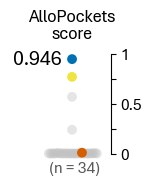

6gx3


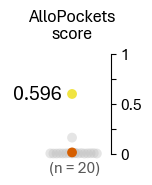

2gk9


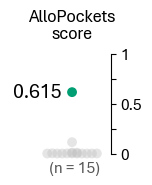

9di9


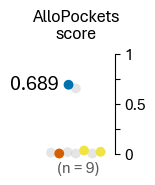

2ojx


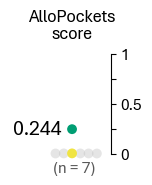

6uen


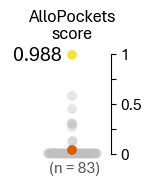

3pfv


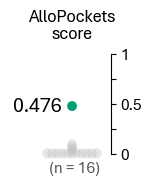

8y6y


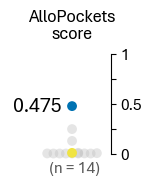

4n22


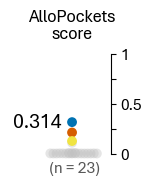

9di2


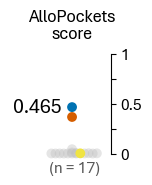

9fsk


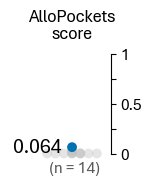

9ouk


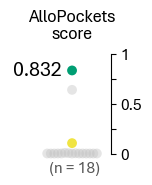

8yf0


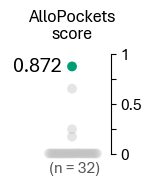

In [26]:
os.makedirs("images", exist_ok=True)

for pdb_id in df["pdb"].drop_duplicates():
    print(pdb_id)
    plot_scatter_panel(
        pdb_id,
        df,
        # save_path=f"{scatter_config['output_prefix']}{pdb_id}.svg",
    )


# Pocket functions

In [27]:
from biotite.structure.io.pdb import PDBFile

def get_pdb_atoms(f):
    atom_array = PDBFile.read(f).get_structure()
    return pd.DataFrame({
            "auth_asym_id": atom_array.chain_id,
            "auth_seq_id": atom_array.res_id,
            "auth_comp_id": atom_array.res_name,
            "auth_atom_id": atom_array.atom_name,
            "type_symbol": atom_array.element,
            "Cartn_x": atom_array.coord[0][:, 0],
            "Cartn_y": atom_array.coord[0][:, 1],
            "Cartn_z": atom_array.coord[0][:, 2],
            "pdbx_PDB_ins_code": (ic or '?' for ic in atom_array.ins_code)
        }, dtype=str)

In [28]:
def get_pocket(pocket_atoms, res_id, color):
    pocket_atoms["label_entity_id"] = '99'
    return {
        "pocketn": res_id,
        "atoms": pocket_atoms, 
        "representation": {
            "selection": [{'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(res_id)}], 
            'color': colors[color]
        }
    }

In [29]:
def get_our_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     Cif(pdb, f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif", name=f"{pdb}_out")
    #     .atoms
    #     .query(f"label_comp_id == 'STP' and label_seq_id == '{pocketn}'")
    # )

    return {
        "pocketsf": f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif",
        "pocketn": pocketn,
        "pocket_sel": [{"label_comp_id": 'STP', "label_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)
# {
#         "atoms": pocket_atoms, 
#         "representation": {
#             "selection": {'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(pocketn)}, 
#             'color': colors[color]
#         }
#     }

models["model5"]["pocketf"] = get_our_pocket

In [30]:
# def get_allositepro_pocket(pdb, pocket, color):
#     resultsf = next(f for f in os.listdir(f"AllositePro/{pdb}") if f.endswith("_download"))
#     # pockets are 0-indexed but residue numbers start at 1
#     # also pocket0 can be residue ID 2, so all pockets auth_seq_id will be sorted and then the relevant residue id taken with the 0-index pocket number
#     pockets_atoms = (
#         get_pdb_atoms(f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb")
#         .query(f"auth_comp_id == 'STP'")
#     )
#     pocketn = sorted(pockets_atoms.auth_seq_id.unique())[ int(pocket.replace('pocket', '')) ]
#     # pocket_atoms = pockets_atoms.query(f"auth_seq_id == '{pocketn}'")
    
#     return {
#         "pocketsf": f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb",
#         "pocketn": pocketn,
#         "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
#         "color": colors[color]
#     }#get_pocket(pocket_atoms, pocketn, color)

# models["allositepro"]["pocketf"] = get_allositepro_pocket

In [31]:
from functools import partial

In [32]:
# def get_passer_pocket(pdb, pocket, color, model):
#     pocketn = pocket.replace('pocket', '')
#     # pocket_atoms = (
#     #     get_pdb_atoms(f"PASSer/{model}/{pdb}/{pdb}_out.pdb")
#     #     .query(f"auth_comp_id == 'STP' and auth_seq_id == '{pocketn}'")
#     # )
    
#     return {
#         "pocketsf": f"PASSer/{model}/{pdb}/{pdb}_out.pdb",
#         "pocketn": pocketn,
#         "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
#         "color": colors[color]
#     }#get_pocket(pocket_atoms, pocketn, color)

# models["passer_ensemble"]["pocketf"] = partial(get_passer_pocket, model="ensemble")
# models["passer_automl"]["pocketf"] = partial(get_passer_pocket, model="automl")
# models["passer_rank"]["pocketf"] = partial(get_passer_pocket, model="rank")

# View functions

In [33]:
import molviewspec as mvs
import json
from pathlib import Path

In [34]:
import numpy as np

In [35]:
# ass_fields_list = ["_pdbx_struct_assembly", "_pdbx_struct_assembly_gen", "_pdbx_struct_oper_list"]

def view_pockets(pdb, model, pockets:list):
    cif = Cif(pdb, f"{extra_set_path}/origcifs/{pdb}_updated.cif.gz")
    
    site = news_sites[pdb][0]
    if pdb == "8sgj":
        site["site"] = site["site"].loc[lambda x: x["label_seq_id"].astype(int) < 800]
    # elif pdb == "7sns" and model == "mefallosite":
    #     site = news_sites[pdb][1]
    
    builder = mvs.create_builder()
    transformation = custom_vizs[pdb]["camera"].get("transformation", None)
    if transformation is not None:
        transformation = transformation.get(model, transformation["transformation"])
        if len(transformation) == 2:
            rot, trans = transformation
        else:
            M = np.array(transformation).reshape(4,4,order="F")
            rot, trans = M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()
        structure = (
            builder.download(url=f"{pdb}.cif")
            .parse(format="mmcif")
            .model_structure()
            .transform(rotation=rot, translation=trans)
        )
    else:
        structure = (
            builder.download(url=f"{pdb}.cif")
            .parse(format="mmcif")
            .model_structure()
        )

    assets = {f'{pdb}.cif': cif.cif.text.encode()}


    if custom_vizs[pdb]["camera"]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"]["camera"].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )
    if model in custom_vizs[pdb]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"][model].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )

    # Protein and site
    for auth_asym_id, siteres in site["site"].groupby("auth_asym_id"):
        protein = (
            structure
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in custom_vizs[pdb]["selections"].get(f"protein_{auth_asym_id}", [{"auth_asym_id": auth_asym_id},])
            ])
            .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
            .color(color='#DADADA')
        )
        annos = f'annos_chain_{auth_asym_id}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'black' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in siteres.iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')

        if model == "model5":
            for i, osite in enumerate(ortho_sites.get(pdb, [])):
                osite = osite.query(f"auth_asym_id == '{auth_asym_id}'").merge(
                    siteres,
                    how="left", indicator=True
                ).query("_merge == 'left_only'").drop(columns="_merge")
                
                if len(osite) == 0: continue
                annos = f'ortho_annos_{auth_asym_id}_{i}.json'
                assets[annos] = json.dumps(
                    [
                        {
                            'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                            'color': colors["yellow"] # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                        }
                        for i, r in osite.iterrows()
                    ]
                ).encode()
                protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
                
            
    # Ligands
    if not custom_vizs[pdb]["ligands"]["none"]:
        for entity_id in pd.DataFrame(cif.cif.data["_entity"], dtype=str).query("type == 'non-polymer'").id.unique():
            # if entity_id not in site["mod"].label_entity_id.unique():
            (
                structure
                .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
                .representation(type="ball_and_stick", custom={"molstar_representation_params": {"ignoreLight": True}})
                .color(color="white")
            )
    if model in custom_vizs[pdb]["ligands"]:
        for lig in custom_vizs[pdb]["ligands"][model]:
            (
                structure
                .component(selector=mvs.ComponentExpression(**lig))
                .representation(
                    type="ball_and_stick", 
                    size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
                    custom={"molstar_representation_params": {"ignoreLight": True}})
                .color(
                    custom={
                        "molstar_color_theme_name": "element-symbol",
                        "molstar_color_theme_params": {
                            "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
                        }
                    }
                )
                # .opacity(opacity=0.9)
            )

    # Pockets
    pockets_strs = {}
    for i, pocket in enumerate(pockets):
        pocketf = Path(pocket["pocketsf"])
        name = pocketf.name
        if name not in assets:
            # if "transformation" in custom_vizs[pdb]["camera"]:
            if transformation is not None:
                pockets_strs[name] = (
                    builder.download(url=name)
                    .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                    .model_structure()
                    .transform(rotation=rot, translation=trans)
                )
            else:
                pockets_strs[name] = (
                    builder.download(url=name)
                    .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                    .model_structure()
                )
            with open(pocketf, "r") as f:
                assets[name] = f.read().encode()
        
        (
            pockets_strs[name]
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in pocket["pocket_sel"]
            ])
            .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(color=pocket["color"])
            .opacity(
                opacity=(
                    custom_vizs[pdb]["pocket_opacity"]
                    .get(model, {pocket["pocketn"]: 0.5})
                    .get(pocket["pocketn"])
                )
            )
        )
    


    # View
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )
    # v = mvsx.molstar_notebook(width= 1725, height= 875)
    # return v

In [36]:
def view_top(pdb, model, top=None):
    pocketf = models[model]["pocketf"]
    prob_key = models[model]["prob_key"]
    results = models[model]["results"][pdb]
    labelled = models[model]["labelled"].query(f"pdb == '{pdb}'").sort_values("prob", ascending=False)
    pos_pockets = labelled[labelled["label"] == 1]

    if top is None:
        top = labelled["label"].sum() or 1
    top_pockets = tuple(pocket for i, pocket in tuple(labelled.iterrows())[:top])

    for pocket in top_pockets:
        print(pocket["pocket"], {k: v for k, v in results[pocket["pocket"]].items() if k != "residues"}, "label:", pocket["label"])
        
    return view_pockets(
        pdb,
        model,
        tuple(
            [
                pocketf(pdb, pocket["pocket"], "green" if pocket["label"] == 1 else "blue")
                for pocket in top_pockets
            ] + [
                pocketf(pdb, pocket["pocket"], "orange")
                for i, pocket in pos_pockets.iterrows()
                if pocket["pocket"] not in (p["pocket"] for p in top_pockets)
            ]
        )
    )

# Viz

In [164]:
holo_vizs = pd.read_pickle("../other_tools/custom_vizs.pkl")

len(holo_vizs), holo_vizs

(24,
 {'21du': {'camera': {'camera': '{\n    position: [197.91, 118.59, 113.87],\n    target: [138.75, 136.26, 117.36],\n    up: [-0.11, -0.16, -0.98],\n}'},
   'ligands': {'none': True},
   'selections': {},
   'pocket_opacity': {}},
  '22mj': {'camera': {'camera': '{\n    position: [33.4, 22.11, 50.66],\n    target: [-0.74, 31.2, 18.56],\n    up: [0.69, 0.31, -0.65],\n}'},
   'ligands': {'none': True, 'model5': [{'label_asym_id': 'G'}]},
   'selections': {},
   'pocket_opacity': {}},
  '6s3a': {'camera': {'camera': '{\n    position: [11.93, -29.86, -20.95],\n    target: [-13.23, -12.04, 18.06],\n    up: [-0.44, -0.89, 0.12],\n}'},
   'ligands': {'none': True},
   'selections': {},
   'pocket_opacity': {}},
  '6vvq': {'camera': {'camera': '{\n    position: [-28.97, -46.93, -64.28],\n    target: [-33.26, 2.29, -47.04],\n    up: [0.82, -0.12, 0.56],\n}'},
   'ligands': {'none': True},
   'selections': {},
   'pocket_opacity': {}},
  '6z1m': {'camera': {'camera': '{\n    position: [18.94

In [165]:
with open(f"../../training_data/7.Extra_set/news_sites.pkl", "rb") as f:
    holo_chains = {k: v[0]["site"].label_asym_id.unique().item() for k,v in pickle.load(f).items() if k in apos}

len(holo_chains), holo_chains

(19,
 {'6z1m': 'A',
  '7gqu': 'A',
  '7p2v': 'A',
  '7qpn': 'A',
  '7yg5': 'A',
  '7zpe': 'A',
  '8crc': 'A',
  '8f4s': 'A',
  '8fpi': 'A',
  '8jp0': 'A',
  '8qtk': 'A',
  '8v81': 'A',
  '9dol': 'A',
  '9ebs': 'C',
  '9fsj': 'A',
  '9mfs': 'A',
  '9prs': 'A',
  '9oul': 'B',
  '8y6w': 'E'})

In [166]:
apos

{'8jp0': {'8sgj': ['A']},
 '8f4s': {'7l6r': ['A']},
 '7gqu': {'6yhr': ['A']},
 '7yg5': {'7xlq': ['A']},
 '8v81': {'5uak': ['A']},
 '6z1m': {'6z1h': ['A']},
 '9mfs': {'8szq': ['A']},
 '7p2v': {'6gx3': ['D']},
 '7qpn': {'2gk9': ['A']},
 '7zpe': {'9di9': ['A']},
 '8crc': {'2ojx': ['A']},
 '8fpi': {'6uen': ['A']},
 '8qtk': {'3pfv': ['A']},
 '8y6w': {'8y6y': ['A']},
 '9dol': {'4n22': ['A']},
 '9ebs': {'9di2': ['B']},
 '9fsj': {'9fsk': ['A']},
 '9oul': {'9ouk': ['B']},
 '9prs': {'8yf0': ['A']}}

In [167]:
rev_apos = {tuple(v.keys())[0]: k for k, v in sorted(apos.items(), key=lambda x: tuple(x[1].keys())[0])}
rev_apos

{'2gk9': '7qpn',
 '2ojx': '8crc',
 '3pfv': '8qtk',
 '4n22': '9dol',
 '5uak': '8v81',
 '6gx3': '7p2v',
 '6uen': '8fpi',
 '6yhr': '7gqu',
 '6z1h': '6z1m',
 '7l6r': '8f4s',
 '7xlq': '7yg5',
 '8sgj': '8jp0',
 '8szq': '9mfs',
 '8y6y': '8y6w',
 '8yf0': '9prs',
 '9di2': '9ebs',
 '9di9': '7zpe',
 '9fsk': '9fsj',
 '9ouk': '9oul'}

In [168]:
import requests, time, json

def get_transform(a:tuple, b:tuple) -> np.array:
    q={
      "context":{"mode":"pairwise","method":{"name":"tm-align"},"structures":[
        {"entry_id":a[0],"selection":{"asym_id":a[1]}}, # label_asym_id
        {"entry_id":b[0],"selection":{"asym_id":b[1]}}
      ]}
    }
    
    submit_resp = requests.post(
        "https://alignment.rcsb.org/api/v1/structures/submit",
        data={"query": json.dumps(q)},
        timeout=30,
    )
    submit_resp.raise_for_status()
    uuid = submit_resp.text.strip() # this is a plain string
    
    # Poll until done
    i = 0
    while True:
        r = requests.get(
            "https://alignment.rcsb.org/api/v1/structures/results",
            params={"uuid": uuid},
            timeout=30,
        ).json()
        # r = resp.json()

        if "info" in r:
            status = r["info"]["status"]
            if status == "COMPLETE":
                break
            if status in {"ERROR", "FAILED"}:
                raise RuntimeError(r["info"])

        time.sleep(0.5)

        
    M = np.array(
        r["results"][0]["structure_alignment"][0]["transformations"][1]
    ).reshape(4,4,order="F")
    return M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()

# get_transform(("8sgj", "A"), ("8jp0", "A"))

In [169]:
transformsf = f"transforms.pkl"

if os.path.isfile(transformsf):
    transforms = pd.read_pickle(transformsf)
else:
    transforms = {}

for p in set(news.keys()) - set(transforms.keys()):
    # if p == "8yf0": continue
    holo = rev_apos[p]
    transforms[p] = get_transform( (holo, holo_chains[holo]), (p, apos[holo][p][0]),)
    pd.to_pickle(transforms, transformsf)
    # break

transforms.keys(), transforms

(dict_keys(['9di9', '7l6r', '6yhr', '9ouk', '6gx3', '9di2', '8sgj', '6uen', '2ojx', '9fsk', '5uak', '6z1h', '7xlq', '8szq', '2gk9', '4n22', '8y6y', '3pfv', '8yf0']),
 {'9di9': ([0.9981296748,
    -0.0492050655,
    -0.0362769054,
    -0.0500788646,
    -0.9984667602,
    -0.0235846601,
    -0.0350607995,
    0.0253572553,
    -0.9990634364],
   [130.4913499658, 132.4771302211, 0.3351000666]),
  '7l6r': ([0.9998240456,
    0.0172236674,
    0.00743122,
    -0.0172999461,
    0.999797028,
    0.0103254359,
    -0.0072518698,
    -0.0104521788,
    0.9999190779],
   [2.1553161573, -0.4889306499, 0.0144072488]),
  '6yhr': ([0.1399118591,
    -0.9748662142,
    -0.1733797453,
    0.9696591642,
    0.1703479943,
    -0.1753358669,
    0.2004639046,
    -0.1435876918,
    0.969121663],
   [20.2964648122, 22.8520055729, -21.8875622483]),
  '9ouk': ([0.9994575272,
    -0.0275101885,
    -0.0181063778,
    0.0284295193,
    0.9982085854,
    0.0526439215,
    0.0166256976,
    -0.0531301192,
   

In [170]:
custom_vizs = {
    p: {
        "camera": {
            "camera": holo_vizs[rev_apos[p]]["camera"]["camera"],
            # model-specific camera
            "transformation": {
                "transformation": transforms[p],
                # model-specific transformation?
            }
            # model-specific camera after trans?
        }, # set a common camera after revision; also model-specific
        "ligands": {"none": False}, # set to True after revision; also model-specific; also size_factor
        "selections": {},
        "pocket_opacity": {}
    }
    for p in news.keys()
}

#### 2gk9 | 7qpn

In [171]:
custom_vizs["2gk9"].update({"ligands": {"none": True}})

#### 2ojx | 8crc

In [172]:
custom_vizs["2ojx"].update({"ligands": {"none": True}})

#### 3pfv | 8qtk

In [173]:
custom_vizs["3pfv"].update({
#     "camera": {
#         "camera": """{
#     position: [31.03, 30.61, 94.01],
#     target: [18.05, 10.31, 31.44],
#     up: [0.18, 0.93, -0.34],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.5759028907,-0.6694201429,-0.4692680819,0,-0.7609016017,-0.6488147176,-0.0082592256,0,-0.298939146,0.361823347,-0.8830171304,0,26.5447597967,8.2235551791,46.6840095568,1]
#         },
#     },
    "ligands": {"none": True,}
})

#### 4n22 | 9dol

In [174]:
custom_vizs["4n22"].update({
#     "camera": {
#         "camera": """{
#     position: [31.03, 30.61, 94.01],
#     target: [18.05, 10.31, 31.44],
#     up: [0.18, 0.93, -0.34],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.5759028907,-0.6694201429,-0.4692680819,0,-0.7609016017,-0.6488147176,-0.0082592256,0,-0.298939146,0.361823347,-0.8830171304,0,26.5447597967,8.2235551791,46.6840095568,1]
#         },
#     },
    "ligands": {"none": True,}
})

#### 5uak | 8v81

In [175]:
custom_vizs["5uak"].update({
#     "camera": {
#         "camera": """{
#     position: [110.01, 224.39, 228.89],
#     target: [150.45, 123.5, 140.12],
#     up: [-0.62, 0.36, -0.69],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [-0.13105706571718778,-0.45247684104623354,-0.8820933929252743,0,-0.9802573751601144,0.1920238121179244,0.04714163790008763,0,0.1480524365547684,0.8708567987312964,-0.4687098378887251,0,292.49179494239024,39.73494877071238,344.4403539798741,1]
#         },
#     },
    "ligands": {"none": True,},
    # "pocket_opacity": {
    #     "model5": {"1": 0.35},
    #     "mefallosite": {"118": 0.65, "35": 0.65}
    # },
})

#### 6gx3 | 7p2v

In [176]:
custom_vizs["6gx3"].update({
#     "camera": {
#         "camera": """{
#     position: [86.62, -30.65, 24.04],
#     target: [94.2, 25.11, 24.15],
#     up: [-0.58, 0.08, 0.81],
# }""",
#     },
    "ligands": {
        "none": True,
        # "size_factor": 0.7,
        "model5": [{"label_asym_id": "EA"},],
        # "allo": [{"label_asym_id": "H"},],
        # "mefallosite": [{"label_asym_id": "H"},],
    }
})

#### 6uen | 8fpi

In [177]:
custom_vizs["6uen"].update({"ligands": {"none": True}})

#### 6yhr | 7gqu

In [178]:
custom_vizs["6yhr"].update({
#     "camera": {
#         "camera": """{
#     position: [77.37, 31.66, 32.78],
#     target: [5.74, 27.52, 18.12],
#     up: [0.04, 0.89, -0.46],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.1399118591,-0.9748662142,-0.1733797453,0,0.9696591642,0.1703479943,-0.1753358669,0,0.2004639046,-0.1435876918,0.969121663,0,20.2964648122,22.8520055729,-21.8875622483,1]
#         },
#     },
    "ligands": {
        "none": True,
        # "size_factor": 0.7,
        "model5": [{"label_asym_id": "B"},],
        # "allo": [{"label_asym_id": "B"},],
        # "mefallosite": [{"label_asym_id": "B"},],
    },
    "selections": {
        "protein_A": [{"label_asym_id": "A", "beg_label_seq_id": 13, "end_label_seq_id": 430},]
    }
})

#### 6z1h | 6z1m

In [179]:
custom_vizs["6z1h"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "E"},{"label_asym_id": "F"},],
    }
})

#### 7l6r | 8f4s

In [180]:
custom_vizs["7l6r"].update({
    "camera": {
        "camera": """{
    position: [87.04, -30.29, 30.96],
    target: [94.2, 25.11, 24.15],
    up: [-0.25, 0.15, 0.96],
}""",
    },
    "ligands": {
        "none": True,
        # "size_factor": 0.7,
        "model5": [{"label_asym_id": "H"},],
        # "allo": [{"label_asym_id": "H"},],
        # "mefallosite": [{"label_asym_id": "H"},],
    },
    "selections": {
        "protein_A": [{"label_asym_id": "A", "beg_label_seq_id": 1, "end_label_seq_id": 295},]
    }
})

#### 7xlq | 7yg5

In [181]:
custom_vizs["7xlq"].update({
    "camera": {
        "camera": """{
    position: [154.13, 263.47, 152.95],
    target: [155.36, 159.67, 169.23],
    up: [0.86, 0.09, 0.51],
}""", # camera of original holo when a transformation is used
#         "model5": """{
#     position: [143.51, 264.08, 162.99],
#     target: [155.86, 159.89, 168.95],
#     up: [0.85, 0.13, 0.51],
# }""",
#         "transformation":  {
#             "transformation": [0.9999010495,-0.0124626843,0.0065247819,0,0.0125041625,0.9999016232,-0.0063552928,0,-0.006444936,0.0064362509,0.9999585179,0,-1.1825644706,1.0517760401,-0.1924989214,1]
#         },
    },
    "ligands": {
        "none": True,
        # "mefallosite": [{"label_asym_id": "Q"},],
    }
})

#### 8sgj | 8jp0

In [182]:
custom_vizs["8sgj"].update({
#     "camera": {
#         "camera": """{
#     position: [103.33, 108.95, 69.94],
#     target: [130.69, 134.14, 126.6],
#     up: [-0.91, 0.09, 0.4],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [-0.3653714725,-0.9250073087,-0.1042361066,0,0.3911907883,-0.2541901909,0.884509533,0,-0.8446735785,0.2823983458,0.4547281827,0,260.9762416101,255.1398289019,-59.2357144169,1]
#         },
#     },
    "ligands": {"none": True,},
    # "pocket_opacity": {
    #     "model5": {"1": 0.35},
    #     "allo": {"P_1": 0.4}
    # },
})

#### 8szq | 9mfs

In [183]:
custom_vizs["8szq"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "B"},{"label_asym_id": "I"},],
    }
})

#### 8y6y | 8y6w

In [184]:
custom_vizs["8y6y"].update({
#     "camera": {
#         "camera": """{
#     position: [31.03, 30.61, 94.01],
#     target: [18.05, 10.31, 31.44],
#     up: [0.18, 0.93, -0.34],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.5759028907,-0.6694201429,-0.4692680819,0,-0.7609016017,-0.6488147176,-0.0082592256,0,-0.298939146,0.361823347,-0.8830171304,0,26.5447597967,8.2235551791,46.6840095568,1]
#         },
#     },
    "ligands": {"none": True,}
})

#### 8yf0 | 9prs

In [185]:
custom_vizs["8yf0"].update({
    "ligands": {"none": True,},
    "selections": {
        "protein_B": [{"label_asym_id": "A", "beg_label_seq_id": 133, "end_label_seq_id": 482},
                      {"label_asym_id": "A", "beg_label_seq_id": 587, "end_label_seq_id": 709},]
    }
})

#### 9di2 | 9ebs

In [186]:
custom_vizs["9di2"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "E"},],
    }
})

#### 9di9 | 7zpe

In [187]:
custom_vizs["9di9"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "B"},],
    }
})

#### 9fsk | 9fsj

In [188]:
# custom_vizs["9fsk"].update({
#     "ligands": {
#         "none": True,
#         "model5": [{"label_asym_id": "B"},],
#     }
# })

#### 9ouk | 9oul

In [189]:
custom_vizs["9ouk"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "E"},],
    }
})

pd.to_pickle(custom_vizs, "custom_vizs.pkl")


## View

In [190]:
# 8f4s, 7yg5 90º

In [191]:
print(sorted(news.keys()))

['2gk9', '2ojx', '3pfv', '4n22', '5uak', '6gx3', '6uen', '6yhr', '6z1h', '7l6r', '7xlq', '8sgj', '8szq', '8y6y', '8yf0', '9di2', '9di9', '9fsk', '9ouk']


In [192]:
modell = ["model5",]# "mefallosite", "allo",]#"allositepro",

In [193]:
i = 0

In [194]:
curr_model = modell[i]; print(curr_model)
# i += 1
# mvsx = 
view_top('4n22', curr_model)#; mvsx.molstar_notebook(width= 1100, height= 500)#(width= 1500, height= 600)#

model5
pocket2 {'prob': 0.3144627511501312, 'pred': 0, 'label': 0, 'max_overlap': 0.15625, 'pocket_in_site': 0.15625, 'site_in_pocket': 0.13157894736842105} label: 0


<IPython.core.display.Javascript object>

### Save

In [195]:
import hashlib
import json
import os
import subprocess
import tempfile
from pathlib import Path

from PIL import Image, ImageChops


def get_custom_viz_hash(pdb, ndigits=10):
    payload = json.dumps(custom_vizs[pdb], sort_keys=True).encode()
    return hashlib.sha1(payload).hexdigest()[:ndigits]


def get_render_out_prefix(pdb, images_dir="images"):
    return Path(images_dir) / f"{pdb}_{get_custom_viz_hash(pdb)}"

In [196]:
def render_mvsx_to_png(
    mvsx_obj,
    out_prefix,
    size="7200x5400",
    autocrop=True,
    keep_uncropped=False,
    render_sh=None,
    timeout_sec=600,
):
    """Render MolViewSpec MVSX to PNG using ``mvs-render/render-mvsx.sh``. The ``.mvsx`` is written to a temp file and deleted."""
    out_prefix = Path(out_prefix)
    out_prefix.parent.mkdir(parents=True, exist_ok=True)
    png_path = out_prefix.with_suffix(".png")
    raw_png = out_prefix.with_name(out_prefix.stem + "_raw").with_suffix(".png")
    script = Path(render_sh or Path().cwd() / "mvs-render" / "render-mvsx.sh").resolve()
    if not script.is_file():
        raise FileNotFoundError(
            f"{script} not found — use kernel cwd = other_tools or pass render_sh="
        )

    fd, tmp_mvsx = tempfile.mkstemp(suffix=".mvsx")
    os.close(fd)
    try:
        mvsx_obj.dump(tmp_mvsx)
        cmd = [str(script), "-i", tmp_mvsx, "-o", str(png_path), "--size", size]
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_sec)
        if proc.returncode != 0:
            raise RuntimeError(
                f"mvs-render failed ({proc.returncode})\n{proc.stdout}\n{proc.stderr}"
            )
    finally:
        os.unlink(tmp_mvsx)

    if not png_path.is_file():
        raise FileNotFoundError(png_path)

    png_raw_path = None
    if autocrop:
        im = Image.open(png_path).convert("RGBA")
        w, h = im.size
        alpha = im.split()[-1]
        alpha_bbox = alpha.getbbox()
        alpha_uniform = alpha.getextrema()[0] == alpha.getextrema()[1]
        use_white_trim = alpha_bbox is None or alpha_uniform or alpha_bbox == (0, 0, w, h)
        if use_white_trim:
            rgb = im.convert("RGB")
            bg = Image.new("RGB", (w, h), (255, 255, 255))
            diff = ImageChops.difference(rgb, bg)
            r, g, b = diff.split()

            def max2(a, b):
                return ImageChops.lighter(a, b)

            max_rb = max2(r, g)
            max_rgb = max2(max_rb, b)
            tol = 4
            mask = max_rgb.point(lambda p: 255 if p > tol else 0)
            bbox = mask.getbbox()
        else:
            bbox = alpha_bbox
        if bbox:
            cropped = im.crop(bbox)
            if keep_uncropped:
                png_path.replace(raw_png)
                cropped.save(png_path)
                png_raw_path = raw_png
            else:
                cropped.save(png_path)
        else:
            print("Warning: no bbox (fully transparent or empty mask); skipping crop.")

    return {
        "mvsx": None,
        "png_final": str(png_path),
        "png_raw": str(png_raw_path) if png_raw_path and png_raw_path.is_file() else None,
        "stdout": proc.stdout,
        "stderr": proc.stderr,
    }


In [197]:
for pdb in news.keys():
    out_prefix = get_render_out_prefix(pdb)
    if not out_prefix.with_suffix(".png").is_file():
        
        for f in Path("images").iterdir():
            if pdb in f.name:
                f.unlink()
                
        render_mvsx_to_png(
            view_top(pdb, "model5"),
            out_prefix=out_prefix,
            size="7200x5400",
            autocrop=True,
            keep_uncropped=False,
            timeout_sec=300,
            render_sh="../other_tools/mvs-render/render-mvsx.sh"
        )


pocket9 {'prob': 0.49764370918273926, 'pred': 0, 'label': 1, 'max_overlap': 0.5263157894736842, 'pocket_in_site': 0.5263157894736842, 'site_in_pocket': 0.38461538461538464} label: 1
pocket1 {'prob': 0.5108914971351624, 'pred': 1, 'label': 1, 'max_overlap': 0.3793103448275862, 'pocket_in_site': 0.14864864864864866, 'site_in_pocket': 0.3793103448275862} label: 1
pocket3 {'prob': 0.6889505386352539, 'pred': 1, 'label': 0, 'max_overlap': 0.0, 'pocket_in_site': 0.0, 'site_in_pocket': 0.0} label: 0
pocket1 {'prob': 0.4756425619125366, 'pred': 0, 'label': 1, 'max_overlap': 0.6666666666666666, 'pocket_in_site': 0.4444444444444444, 'site_in_pocket': 0.6666666666666666} label: 1
pocket9 {'prob': 0.47492948174476624, 'pred': 0, 'label': 0, 'max_overlap': 0.0, 'pocket_in_site': 0.0, 'site_in_pocket': 0.0} label: 0
pocket2 {'prob': 0.3144627511501312, 'pred': 0, 'label': 0, 'max_overlap': 0.15625, 'pocket_in_site': 0.15625, 'site_in_pocket': 0.13157894736842105} label: 0
pocket2 {'prob': 0.06373907

# Figure

In [181]:
{
    apo: apo
    for k, v in dict(sorted(apos.items(), key=lambda x: tuple(x[0]))).items()
    for apo in (tuple(v.keys())[0],)
}

{'6z1h': '6z1h',
 '6yhr': '6yhr',
 '6gx3': '6gx3',
 '2gk9': '2gk9',
 '7xlq': '7xlq',
 '9di9': '9di9',
 '2ojx': '2ojx',
 '7l6r': '7l6r',
 '6uen': '6uen',
 '8sgj': '8sgj',
 '8vw5': '8vw5',
 '5uak': '5uak',
 '9di2': '9di2',
 '9fsk': '9fsk',
 '8szq': '8szq',
 '8yf0': '8yf0',
 '9ouk': '9ouk'}

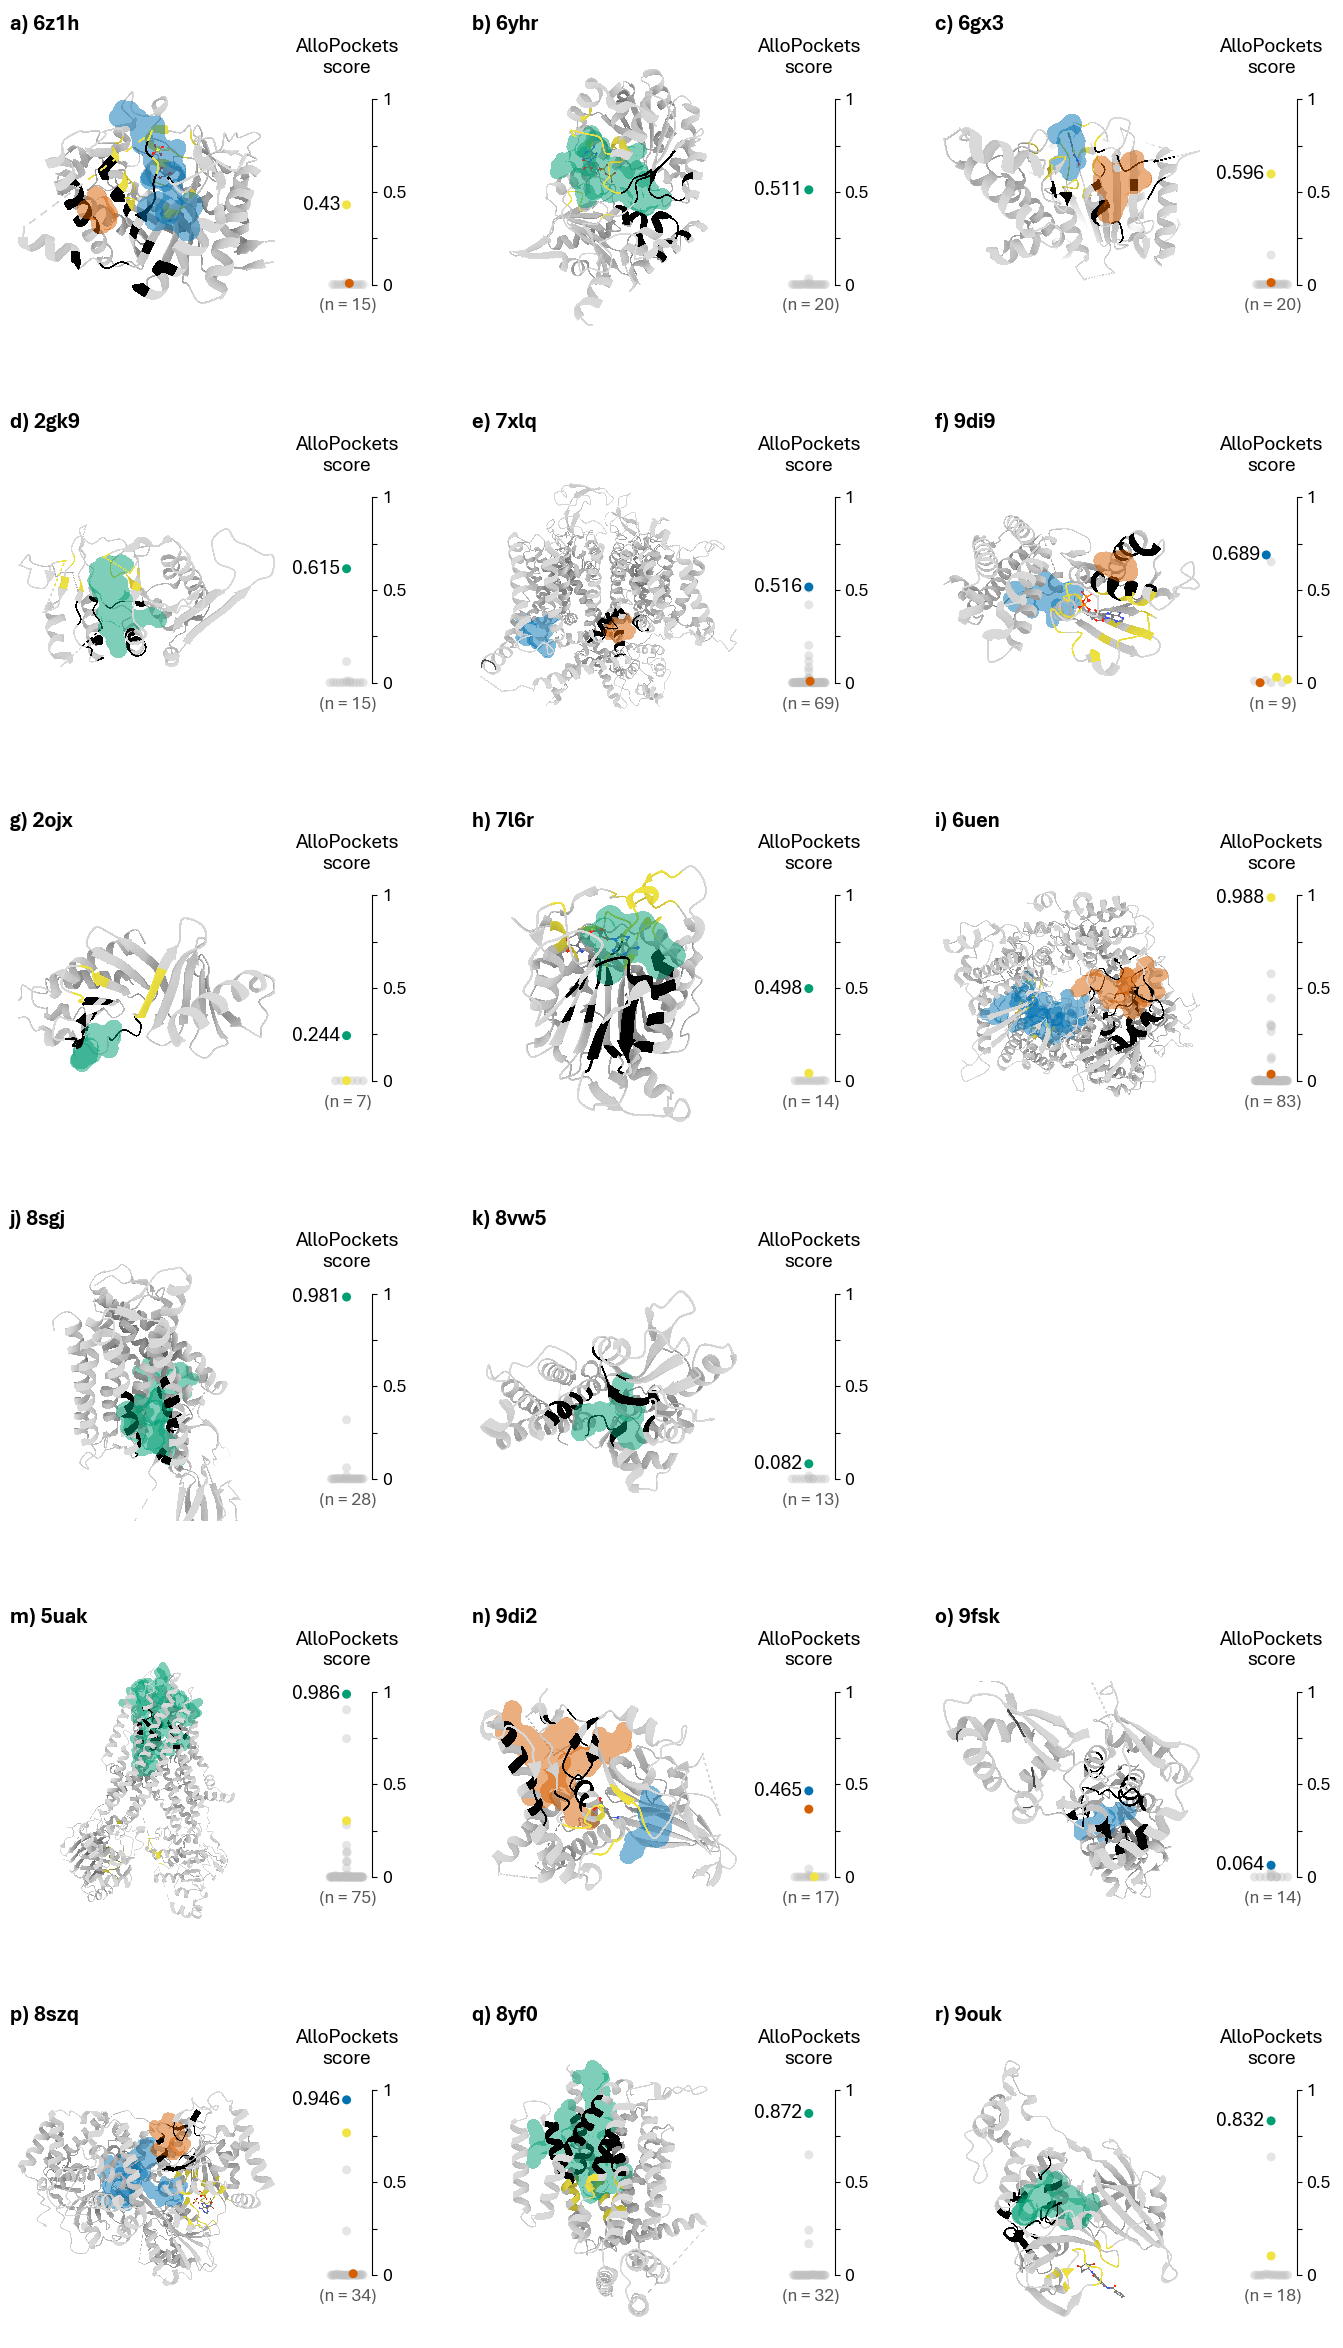

Saved multi-panel figure to images/multipanel_figure.svg


In [184]:
from pathlib import Path
from string import ascii_lowercase

import matplotlib.image as mpimg
from matplotlib import rcParams

names = {
    '6z1h': '6z1h',
    '6yhr': '6yhr',
    '6gx3': '6gx3',
    '2gk9': '2gk9',
    '7xlq': '7xlq',
    '9di9': '9di9',
    '2ojx': '2ojx',
    '7l6r': '7l6r',
    '6uen': '6uen',
    '8sgj': '8sgj',
    '8vw5': '8vw5',
    '5uak': '5uak',
    '9di2': '9di2',
    '9fsk': '9fsk',
    '8szq': '8szq',
    '8yf0': '8yf0',
    '9ouk': '9ouk'
}
# Titles can use Matplotlib mathtext for italics, e.g. r"22mj | $\it{Protein\ Name}$"
# TODO: add explicit line breaks ("\n") for titles that should span two lines.

figure_config = {
    "ncols": 3,
    "nrows": 6,
    "figsize": (14, 24),
    "font_scale": 1.15,
    "left": 0.04,
    "right": 0.985,
    "top": 0.99,
    "bottom": 0.02,
    "wspace": 0.16,
    "hspace": 0.18,
    "panel_hspace": 0.008,
    "panel_wspace": 0.02,
    "title_height_ratio": 0.11,
    "image_height_ratio": 0.89,
    "protein_width_ratio": 0.72,
    "scatter_width_ratio": 0.32,
    "protein_max_width": 0.94,
    "protein_max_height": 0.94,
    "panel_label_fontsize": 14,
    "panel_label_weight": "bold",
    "title_fontsize": 14,
    "header_fontweight": "bold",
    "label_x": 0.0,
    "title_x": 0.12,
    "title_y": 0.6,
    "panel_facecolor": "none",
    "figure_facecolor": "none",
    "scatter_config": {
        **scatter_config,
        "figsize": (2.2, 2.8),
        "point_size": 42,
        "tick_fontsize": 11.8,
        "label_fontsize": 12.8,
        "xlabel_fontsize": 11.8,
        "score_title_fontsize": 13.4,
    },
    "output_path": "images/multipanel_figure.svg",
}

font_scale = figure_config["font_scale"]
figure_config["panel_label_fontsize"] *= font_scale
figure_config["title_fontsize"] *= font_scale
for key in ["tick_fontsize", "label_fontsize", "xlabel_fontsize", "score_title_fontsize"]:
    figure_config["scatter_config"][key] *= font_scale

plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"


def draw_centered_image(ax, image_path, max_width=0.94, max_height=0.94):
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing protein render for {image_path.stem}: {image_path}")

    img = mpimg.imread(image_path)
    height, width = img.shape[:2]
    aspect = width / height

    disp_width = max_width
    disp_height = disp_width / aspect
    if disp_height > max_height:
        disp_height = max_height
        disp_width = disp_height * aspect

    x0 = (1 - disp_width) / 2
    x1 = x0 + disp_width
    y0 = (1 - disp_height) / 2
    y1 = y0 + disp_height

    ax.imshow(
        img,
        extent=(x0, x1, y0, y1),
        aspect="auto",
        interpolation="none",
        resample=False,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_facecolor("none")
    ax.axis("off")


pdb_order = list(names)
# assert len(pdb_order) == figure_config["ncols"] * figure_config["nrows"]

fig = plt.figure(figsize=figure_config["figsize"], facecolor=figure_config["figure_facecolor"])
outer = fig.add_gridspec(
    figure_config["nrows"],
    figure_config["ncols"],
    left=figure_config["left"],
    right=figure_config["right"],
    top=figure_config["top"],
    bottom=figure_config["bottom"],
    wspace=figure_config["wspace"],
    hspace=figure_config["hspace"],
)

for panel_idx, pdb_id in enumerate(pdb_order):
    if panel_idx >= 11:
        panel_idx += 1
    row = panel_idx // figure_config["ncols"]
    col = panel_idx % figure_config["ncols"]
    header = f"{ascii_lowercase[panel_idx]}) {names[pdb_id]}"

    panel = outer[row, col].subgridspec(
        2,
        1,
        height_ratios=[figure_config["title_height_ratio"], figure_config["image_height_ratio"]],
        hspace=figure_config["panel_hspace"],
    )

    title_ax = fig.add_subplot(panel[0])
    title_ax.set_facecolor(figure_config["panel_facecolor"])
    title_ax.axis("off")
    title_ax.text(
        figure_config["label_x"],
        figure_config["title_y"],
        header,
        fontsize=figure_config["title_fontsize"],
        fontweight=figure_config["header_fontweight"],
        ha="left",
        va="center",
    )

    content = panel[1].subgridspec(
        1,
        2,
        width_ratios=[figure_config["protein_width_ratio"], figure_config["scatter_width_ratio"]],
        wspace=figure_config["panel_wspace"],
    )

    protein_ax = fig.add_subplot(content[0])
    protein_ax.set_facecolor(figure_config["panel_facecolor"])
    draw_centered_image(
        protein_ax,
        Path("images") / f"{pdb_id}.png",
        max_width=figure_config["protein_max_width"],
        max_height=figure_config["protein_max_height"],
    )

    scatter_host_ax = fig.add_subplot(content[1])
    scatter_host_ax.set_facecolor(figure_config["panel_facecolor"])
    scatter_host_ax.axis("off")
    scatter_ax = scatter_host_ax.inset_axes([0.15, 0.21, 0.68, 0.62])
    scatter_ax.set_facecolor("none")
    plot_scatter_panel(
        pdb_id,
        df,
        ax=scatter_ax,
        config=figure_config["scatter_config"],
        show_xlabel=True,
        show_score_title=True,
    )

fig.savefig(figure_config["output_path"], transparent=True)
fig.savefig(
    Path(figure_config["output_path"]).with_suffix(".pdf"),#"images/multipanel_figure.pdf",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True,
)
plt.show()
print(f"Saved multi-panel figure to {figure_config['output_path']}")


## Ignorelight tests